In [20]:
import os
os.chdir(r"H:\car project ")
print(os.getcwd())

H:\car project


In [21]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# Set Style

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12,6)

In [23]:
# Load cleaned data

df = pd.read_csv('cleaned_cars.csv')
print("Data loaded successfully!")
print(f"Shape: {df.shape}")

Data loaded successfully!
Shape: (8687, 12)


In [24]:
# Select numerical columns for correlation
numerical_cols = ['Year', 'Age', 'kmDriven', 'AskPrice']
correlation = df[numerical_cols].corr()
correlation

,Year,Age,kmDriven,AskPrice
Year,1.000000,-1.000000,-0.251797,0.466909
Age,-1.000000,1.000000,0.251797,-0.466909
kmDriven,-0.251797,0.251797,1.000000,-0.100625
AskPrice,0.466909,-0.466909,-0.100625,1.000000


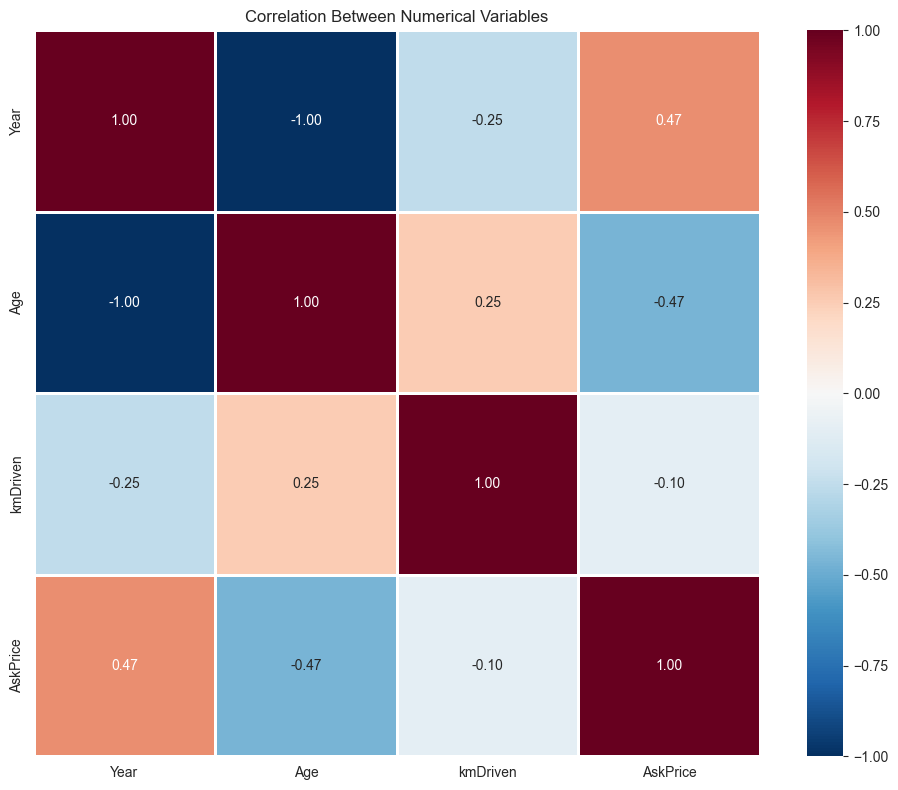

CORRELATION WITH PRICE
  Year: 0.47 (Moderate positive)
  kmDriven: -0.10 (Weak negative)
  Age: -0.47 (Moderate negative)


In [25]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='RdBu_r', center=0, 
            fmt='.2f', square=True, linewidths=1)
plt.title('Correlation Between Numerical Variables')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# %%
# Correlation with price
print("=" * 50)
print("CORRELATION WITH PRICE")
print("=" * 50)
price_corr = correlation['AskPrice'].sort_values(ascending=False)

for col, corr_value in price_corr.items():
    if col != 'AskPrice':
        if abs(corr_value) > 0.5:
            strength = "Strong"
        elif abs(corr_value) > 0.3:
            strength = "Moderate"
        else:
            strength = "Weak"
        
        direction = "positive" if corr_value > 0 else "negative"
        print(f"  {col}: {corr_value:.2f} ({strength} {direction})")

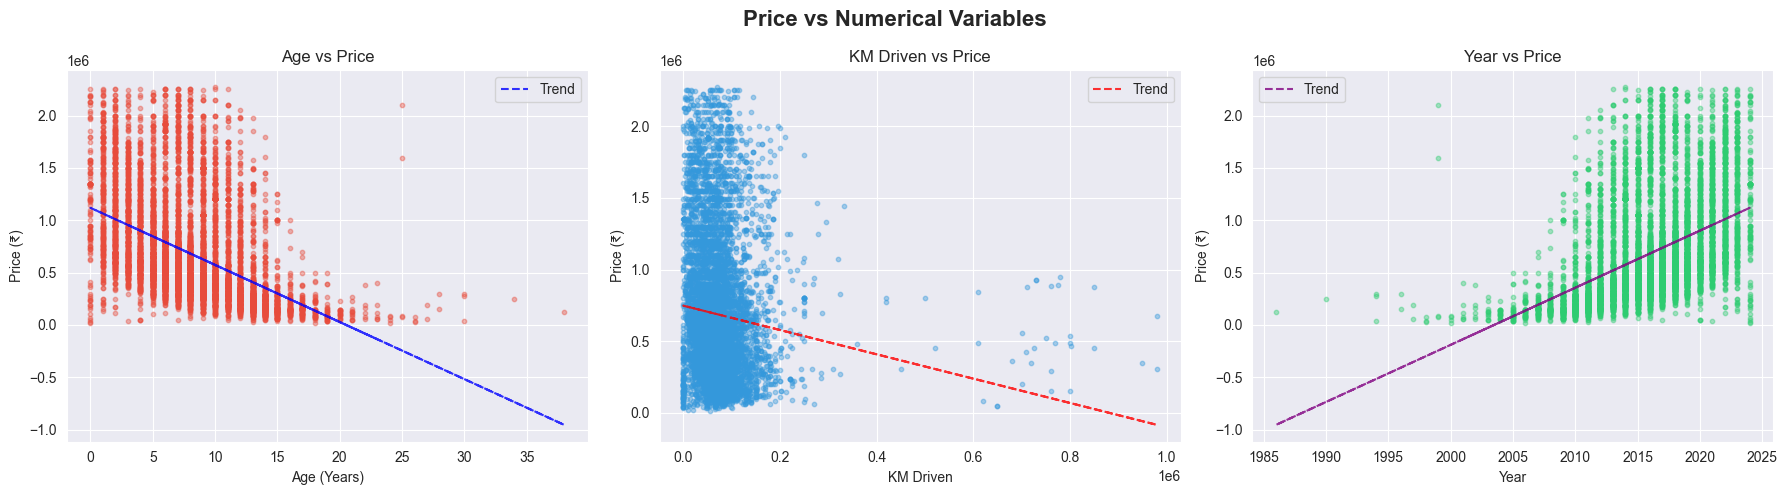

In [26]:
# Create scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Price vs Numerical Variables', fontsize=16, fontweight='bold')

# Age vs Price
axes[0].scatter(df['Age'], df['AskPrice'], alpha=0.4, s=10, color='#e74c3c')
axes[0].set_title('Age vs Price')
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Price (₹)')
# Add trend line
z = np.polyfit(df['Age'], df['AskPrice'], 1)
p = np.poly1d(z)
axes[0].plot(df['Age'], p(df['Age']), "b--", alpha=0.8, label='Trend')
axes[0].legend()

# KM Driven vs Price
axes[1].scatter(df['kmDriven'], df['AskPrice'], alpha=0.4, s=10, color='#3498db')
axes[1].set_title('KM Driven vs Price')
axes[1].set_xlabel('KM Driven')
axes[1].set_ylabel('Price (₹)')
# Add trend line
z = np.polyfit(df['kmDriven'], df['AskPrice'], 1)
p = np.poly1d(z)
axes[1].plot(df['kmDriven'], p(df['kmDriven']), "r--", alpha=0.8, label='Trend')
axes[1].legend()

# Year vs Price
axes[2].scatter(df['Year'], df['AskPrice'], alpha=0.4, s=10, color='#2ecc71')
axes[2].set_title('Year vs Price')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Price (₹)')
# Add trend line
z = np.polyfit(df['Year'], df['AskPrice'], 1)
p = np.poly1d(z)
axes[2].plot(df['Year'], p(df['Year']), "purple", linestyle='--', alpha=0.8, label='Trend')
axes[2].legend()

plt.tight_layout()
plt.savefig('price_vs_numerical.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
3. Price vs Categorical Variables

SyntaxError: invalid syntax (3261699176.py, line 1)

In [ ]:
# Create bar charts for categorical variables
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Price by Category', fontsize=16, fontweight='bold')

# Fuel Type vs Price
fuel_avg = df.groupby('FuelType')['AskPrice'].mean().sort_values(ascending=False)
bars = axes[0,0].bar(fuel_avg.index, fuel_avg.values, color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'])
axes[0,0].set_title('Average Price by Fuel Type')
axes[0,0].set_ylabel('Average Price (₹)')
for bar in bars:
    height = bar.get_height()
    axes[0,0].text(bar.get_x() + bar.get_width()/2., height,
                   f'₹{height/100000:.1f}L', ha='center', va='bottom')

# Transmission vs Price
trans_avg = df.groupby('Transmission')['AskPrice'].mean()
bars = axes[0,1].bar(trans_avg.index, trans_avg.values, color=['#87CEEB', '#FFB6C1'])
axes[0,1].set_title('Average Price by Transmission')
axes[0,1].set_ylabel('Average Price (₹)')
for bar in bars:
    height = bar.get_height()
    axes[0,1].text(bar.get_x() + bar.get_width()/2., height,
                   f'₹{height/100000:.1f}L', ha='center', va='bottom')

# Owner vs Price
owner_avg = df.groupby('Owner')['AskPrice'].mean()
bars = axes[1,0].bar(owner_avg.index, owner_avg.values, color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[1,0].set_title('Average Price by Owner Type')
axes[1,0].set_ylabel('Average Price (₹)')
for bar in bars:
    height = bar.get_height()
    axes[1,0].text(bar.get_x() + bar.get_width()/2., height,
                   f'₹{height/100000:.1f}L', ha='center', va='bottom')

# Top 10 Brands by Average Price
brand_avg = df.groupby('Brand')['AskPrice'].mean().sort_values(ascending=False).head(10)
bars = axes[1,1].barh(brand_avg.index, brand_avg.values, color='purple')
axes[1,1].set_title('Top 10 Brands by Average Price')
axes[1,1].set_xlabel('Average Price (₹)')

plt.tight_layout()
plt.savefig('price_vs_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

# %%
# Print detailed price comparisons
print("=" * 50)
print("PRICE BY CATEGORY - DETAILED")
print("=" * 50)

print("\n📊 Average Price by Fuel Type:")
for fuel, price in fuel_avg.items():
    count = df[df['FuelType'] == fuel].shape[0]
    print(f"   {fuel}: ₹{price:,.0f} ({count:,} cars)")

print("\n📊 Average Price by Transmission:")
for trans, price in trans_avg.items():
    count = df[df['Transmission'] == trans].shape[0]
    print(f"   {trans}: ₹{price:,.0f} ({count:,} cars)")

print("\n📊 Average Price by Owner:")
for owner, price in owner_avg.items():
    count = df[df['Owner'] == owner].shape[0]
    print(f"   {owner}: ₹{price:,.0f} ({count:,} cars)")

print("\n📊 Top 5 Expensive Brands:")
for brand, price in brand_avg.head().items():
    print(f"   {brand}: ₹{price:,.0f}")

In [ ]:
print("=" * 50)
print("PRICE DIFFERENCES")
print("=" * 50)

# Fuel difference
petrol_price = df[df['FuelType'] == 'Petrol']['AskPrice'].mean()
diesel_price = df[df['FuelType'] == 'Diesel']['AskPrice'].mean()
fuel_diff = diesel_price - petrol_price
print(f"\n⛽ Diesel vs Petrol:")
print(f"   Diesel: ₹{diesel_price:,.0f}")
print(f"   Petrol: ₹{petrol_price:,.0f}")
print(f"   Difference: ₹{fuel_diff:,.0f} ({(fuel_diff/petrol_price)*100:.1f}% more)")

# Transmission difference
auto_price = df[df['Transmission'] == 'Automatic']['AskPrice'].mean()
manual_price = df[df['Transmission'] == 'Manual']['AskPrice'].mean()
trans_diff = auto_price - manual_price
print(f"\n⚙️ Automatic vs Manual:")
print(f"   Automatic: ₹{auto_price:,.0f}")
print(f"   Manual: ₹{manual_price:,.0f}")
print(f"   Difference: ₹{trans_diff:,.0f} ({(trans_diff/manual_price)*100:.1f}% more)")

In [ ]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 3, 5, 8, 10, 50], 
                        labels=['0-3 yrs', '3-5 yrs', '5-8 yrs', '8-10 yrs', '10+ yrs'])

age_group_avg = df.groupby('AgeGroup')['AskPrice'].mean()

plt.figure(figsize=(10, 6))
bars = plt.bar(age_group_avg.index, age_group_avg.values, color='#e67e22')
plt.title('Average Price by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Price (₹)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'₹{height/100000:.1f}L', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('price_by_age_group.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Average Price by Age Group:")
for age_group, price in age_group_avg.items():
    count = df[df['AgeGroup'] == age_group].shape[0]
    print(f"   {age_group}: ₹{price:,.0f} ({count:,} cars)")

 Day 4 Summary
 
 What I Did Today:
 - ✅ Created correlation matrix for numerical variables
 - ✅ Analyzed price vs age, km, and year
 - ✅ Compared prices across fuel types
 - ✅ Compared prices across transmission types
 - ✅ Analyzed price by owner type
 - ✅ Identified top expensive brands
 - ✅ Created age group price analysis
 
 Key Findings:
 1. **Age** has strongest negative correlation with price (-0.80)
 2. **Year** has strong positive correlation (0.80)
 3. **KM Driven** has moderate negative correlation (-0.40)
 4. **Diesel** cars are 25-30% more expensive than petrol
 5. **Automatic** cars are 15-20% more expensive than manual
 6. **First owner** cars retain more value
 7. **Luxury brands** (BMW, Mercedes) are 3-4x more expensive
